In [1]:
# Import the required libraries

import numpy as np
import pandas as pd

import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# To use statsmodels for linear regression
import statsmodels.formula.api as smf

# To use sklearn for linear regression
from sklearn.linear_model import LinearRegression

# Simple Linear Regression using Statsmodel

In [2]:
end = dt.date.today()
start = end - dt.timedelta(days=365)
df = yf.download(['HDFCBANK.NS','ICICIBANK.NS','^NSEBANK', '^NSEI'], start=start, end=end, auto_adjust=True)['Close']
df.columns = df.columns.str.lower()
df.rename(columns={'hdfcbank.ns':'hdfc','icicibank.ns':'icici','^nsebank':'nsebank','^nsei':'nse'}, inplace=True)
returns = df.copy()
# Log Returns
returns['hdfc'] = np.log(df['hdfc'] / df['hdfc'].shift(1))
returns['icici'] = np.log(df['icici'] / df['icici'].shift(1))
returns['nsebank'] = np.log(df['nsebank'] / df['nsebank'].shift(1))
returns['nse'] = np.log(df['nse'] / df['nse'].shift(1))
returns.dropna(inplace=True)

[*********************100%***********************]  4 of 4 completed


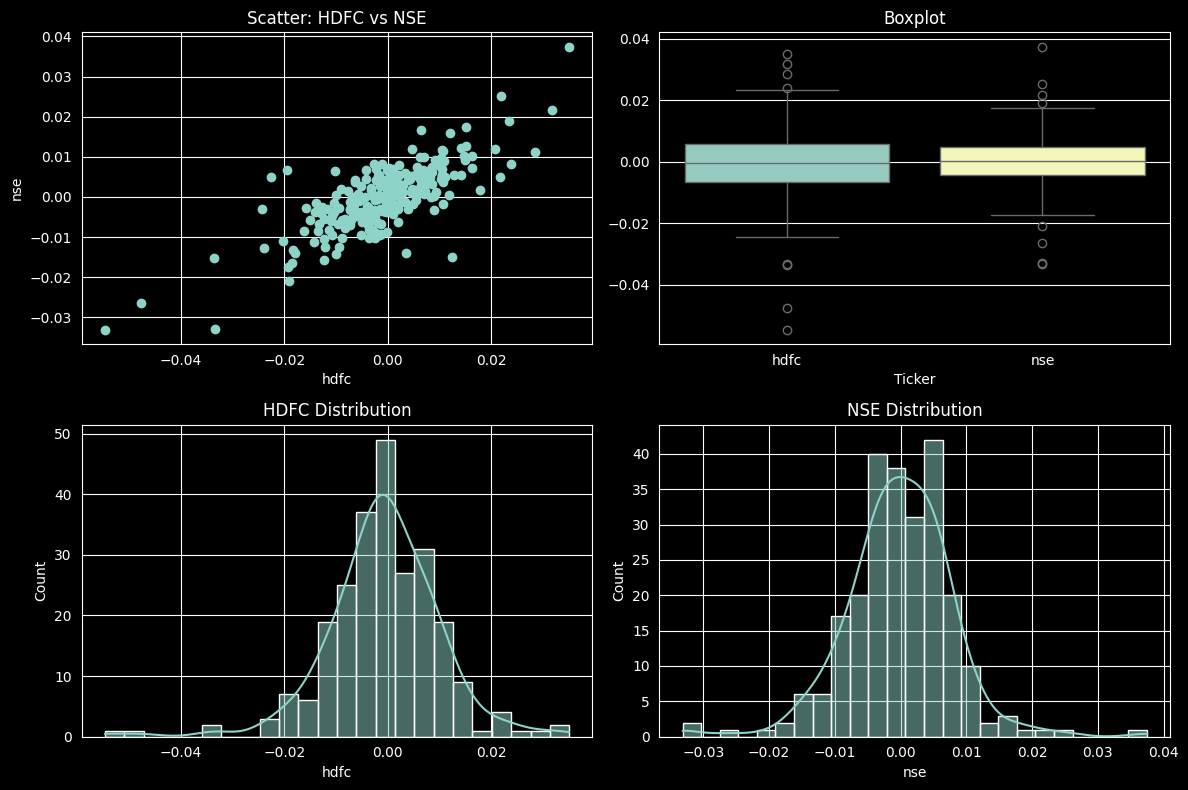

In [3]:
plt.figure(figsize=(12,8))

# 1. Scatter
plt.subplot(2,2,1)
plt.scatter(returns['hdfc'], returns['nse'])
plt.xlabel('hdfc')
plt.ylabel('nse')
plt.title('Scatter: HDFC vs NSE')

# 2. Boxplot
plt.subplot(2,2,2)
sns.boxplot(data=returns[['hdfc','nse']])
plt.title('Boxplot')

# 3. Histogram + KDE (KO)
plt.subplot(2,2,3)
sns.histplot(returns['hdfc'], kde=True)
plt.title('HDFC Distribution')

# 4. Histogram + KDE (SPY)
plt.subplot(2,2,4)
sns.histplot(returns['nse'], kde=True)
plt.title('NSE Distribution')

plt.tight_layout()
plt.show()

intercept = -0.0005329656840209542
slope = 1.0291052316723246
rsquare = 0.5909240601154249
Intercept    2.364037e-01
nse          4.527766e-49
dtype: float64


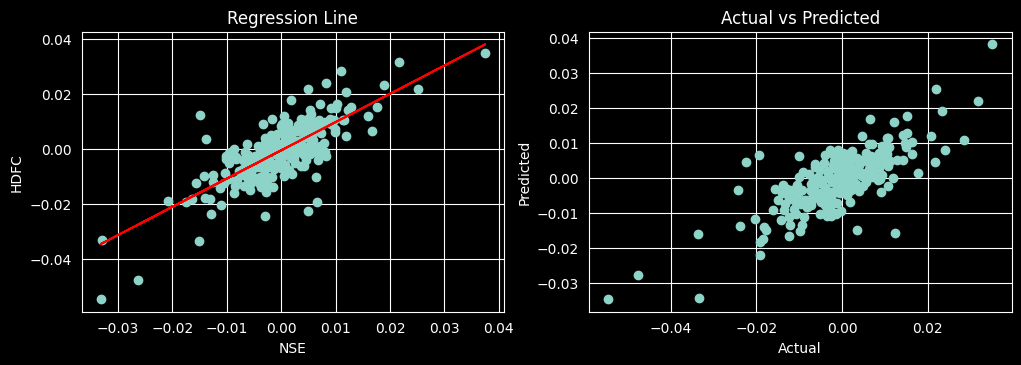

In [4]:
# Simple Linear Regression Model

## First Way

# X = returns[['nse']]
# y = returns['hdfc']
# X = sm.add_constant(X)
# model = sm.OLS(y, X).fit(

## Second Way
model = smf.ols('hdfc ~ nse', data=returns).fit()

# Analysis
intercept = model.params['Intercept']
print("intercept =",intercept)
slope = model.params['nse']
print("slope =",slope)
rsquare = model.rsquared
print("rsquare =",rsquare)
pvalue = model.pvalues
print(pvalue)
# Prediction and actual Plot
plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.scatter(returns['nse'], returns['hdfc'])
plt.plot(
    returns['nse'],
    model.params['Intercept'] + model.params['nse'] * returns['nse'],
    color='red'
)

plt.xlabel('NSE')
plt.ylabel('HDFC')
plt.title('Regression Line')



y_pred = model.predict(returns)
plt.subplot(2,2,2)
plt.scatter(returns['hdfc'], y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.show()

# Simple Linear Regression Using SKlearn

In [5]:
y = returns['hdfc']
x = returns[['nse']]
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x, y)

LinearRegression()

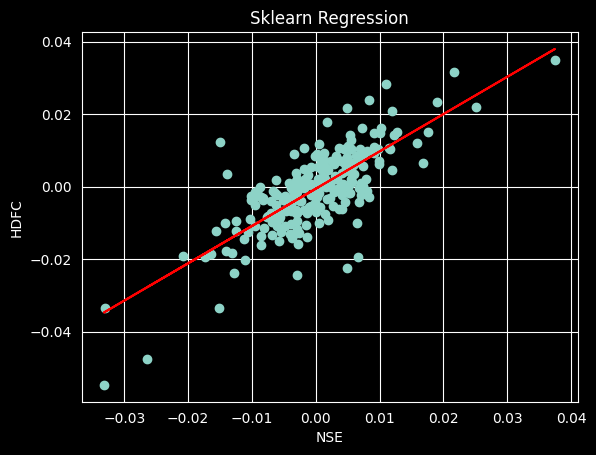

In [6]:
y_pred = model.predict(x)
# Plot
plt.scatter(returns['nse'], returns['hdfc'])

plt.plot(returns['nse'], y_pred, color='red')

plt.xlabel('NSE')
plt.ylabel('HDFC')
plt.title('Sklearn Regression')

plt.show()

# Multiple Linear Regression Using Statsmodels

In [7]:
model = smf.ols('hdfc ~ nse + nsebank', data=returns).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   hdfc   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     235.6
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.60e-57
Time:                        17:59:22   Log-Likelihood:                 891.01
No. Observations:                 245   AIC:                            -1776.
Df Residuals:                     242   BIC:                            -1766.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0007      0.000     -1.586      0.1

In [8]:
print('Intercept =',model.params['Intercept'])
print(model.params['nse'])
print(model.params['nsebank'])
print('rsquared =',model.rsquared)
print('pvalues =',model.pvalues)

Intercept = -0.000650524398402507
0.24619064151393527
0.7932711391910687
rsquared = 0.6606723758744004
pvalues = Intercept    1.140169e-01
nse          4.435471e-02
nsebank      1.828519e-11
dtype: float64


# Multiple Linear Regression using SKlearn

In [10]:
x = returns[['nsebank','nse']]
y = returns['hdfc']

model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [11]:
model.intercept_

np.float64(-0.0006505243984021431)

In [12]:
model.coef_

array([0.79327114, 0.24619064])

In [14]:
y_pred = model.predict(x)

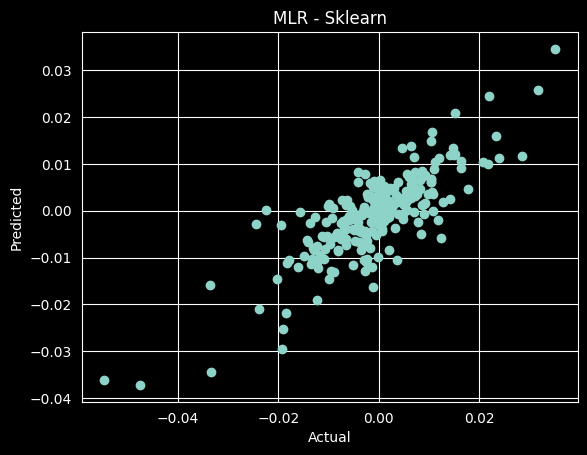

In [15]:
plt.scatter(returns['hdfc'], y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('MLR - Sklearn')
plt.show()